In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Basic Libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

#Data Loading

In [ ]:
# Train
df = pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Training_Labels.csv")
image_paths = "/content/drive/MyDrive/Dataset/Training_Set/Training/" + df["ID"].astype(str) + ".png"

# Validation
val_df= pd.read_csv("/content/drive/MyDrive/Dataset/RFMiD_Validation_Labels.csv")
val_paths = "/content/drive/MyDrive/Dataset/Validation/" + val_df["ID"].astype(str) + ".png"

# Test
test_df = pd.read_csv("/content/drive/MyDrive/Dataset1/RFMiD_Testing_Labels.csv")
test_paths = "/content/drive/MyDrive/Dataset1/Test/" + test_df["ID"].astype(str) + ".png"

# Labels
labels = df["Disease_Risk"].to_numpy()
val_labels = val_df["Disease_Risk"].to_numpy()
test_labels = test_df["Disease_Risk"].to_numpy()

#Log Transform with C=50

In [ ]:
#A custom Function to apply Log Transform with c=50 on the Dataset
def log_transform_c50(image):
    def numpy_func(img):
        img = img.astype(np.float32) / 255.0

        c = 50
        log_img = c * np.log(1 + img)

        log_img = log_img / np.max(log_img)
        log_img = (log_img * 255).astype(np.uint8)

        return log_img

    img = tf.numpy_function(numpy_func, [image], tf.uint8)
    img.set_shape((224, 224, 3))
    img = tf.cast(img, tf.float32) / 255.0

    return img

#Load Dataset

In [ ]:
data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))

    image = log_transform_c50(image)

    return image, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

#Visualization

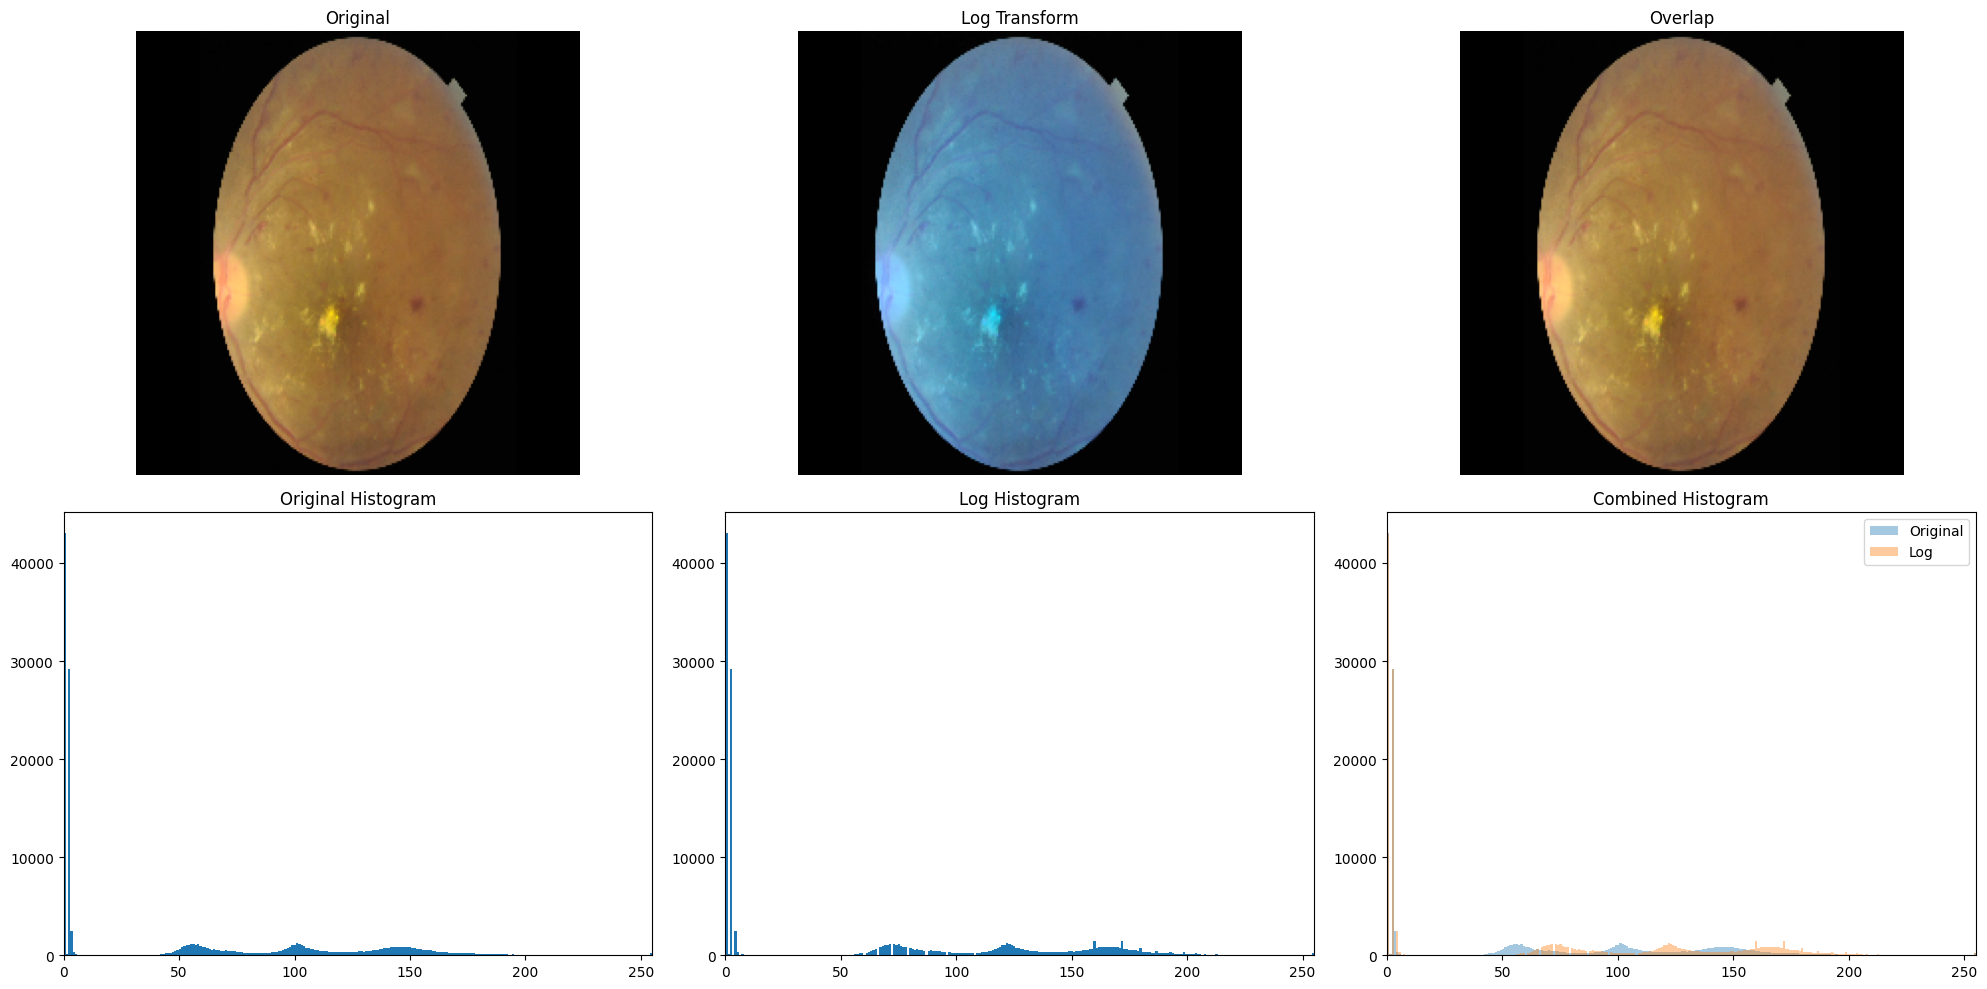

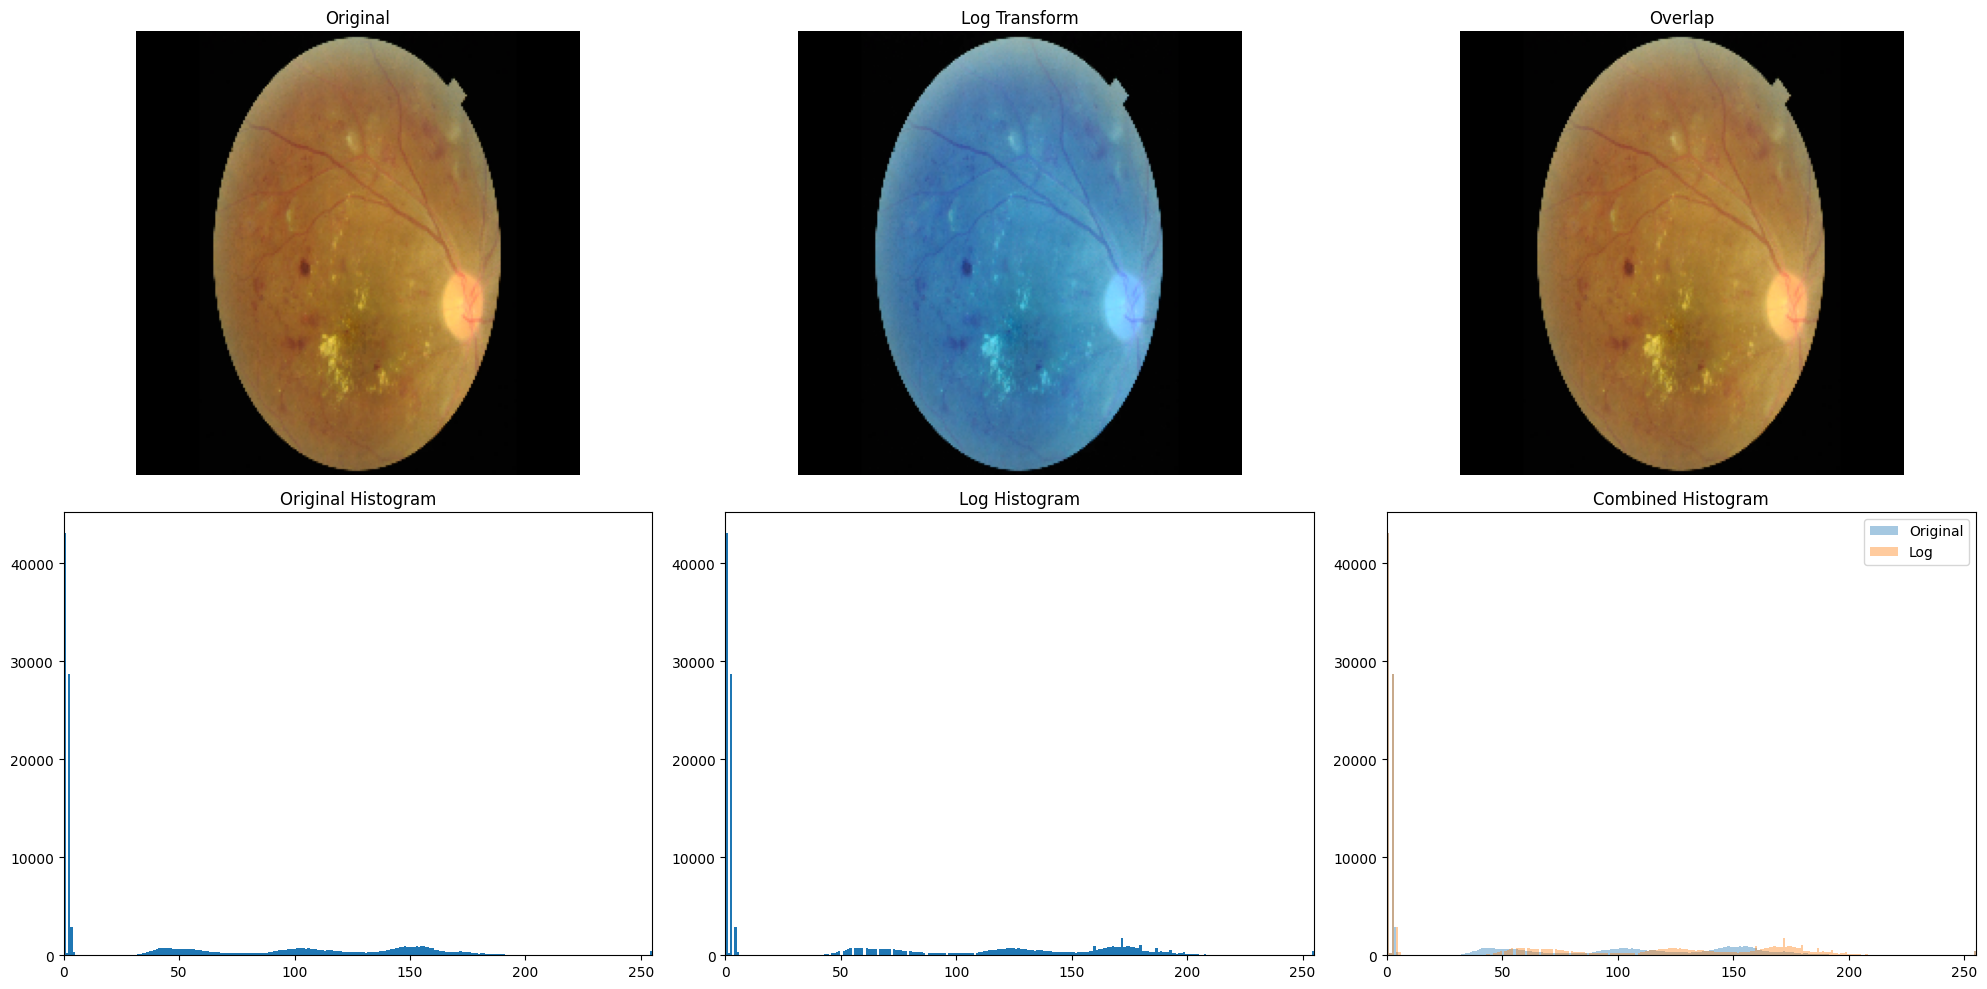

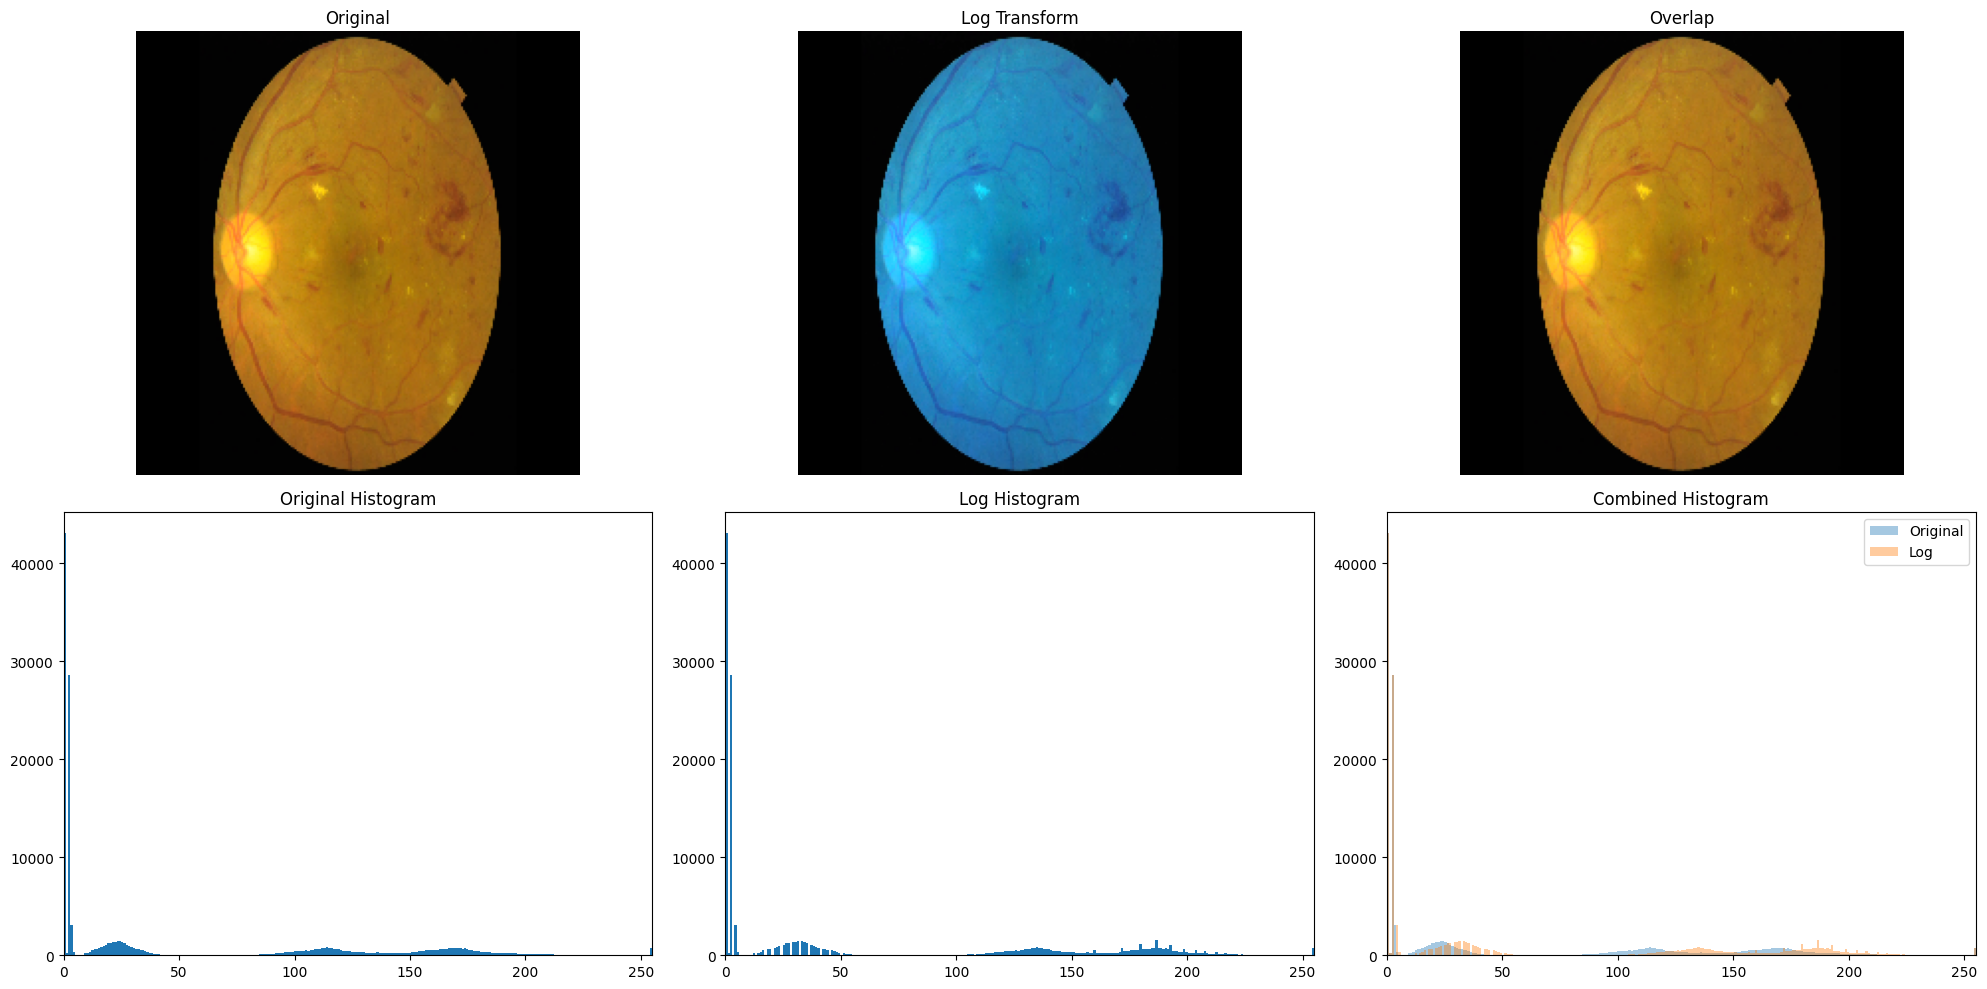

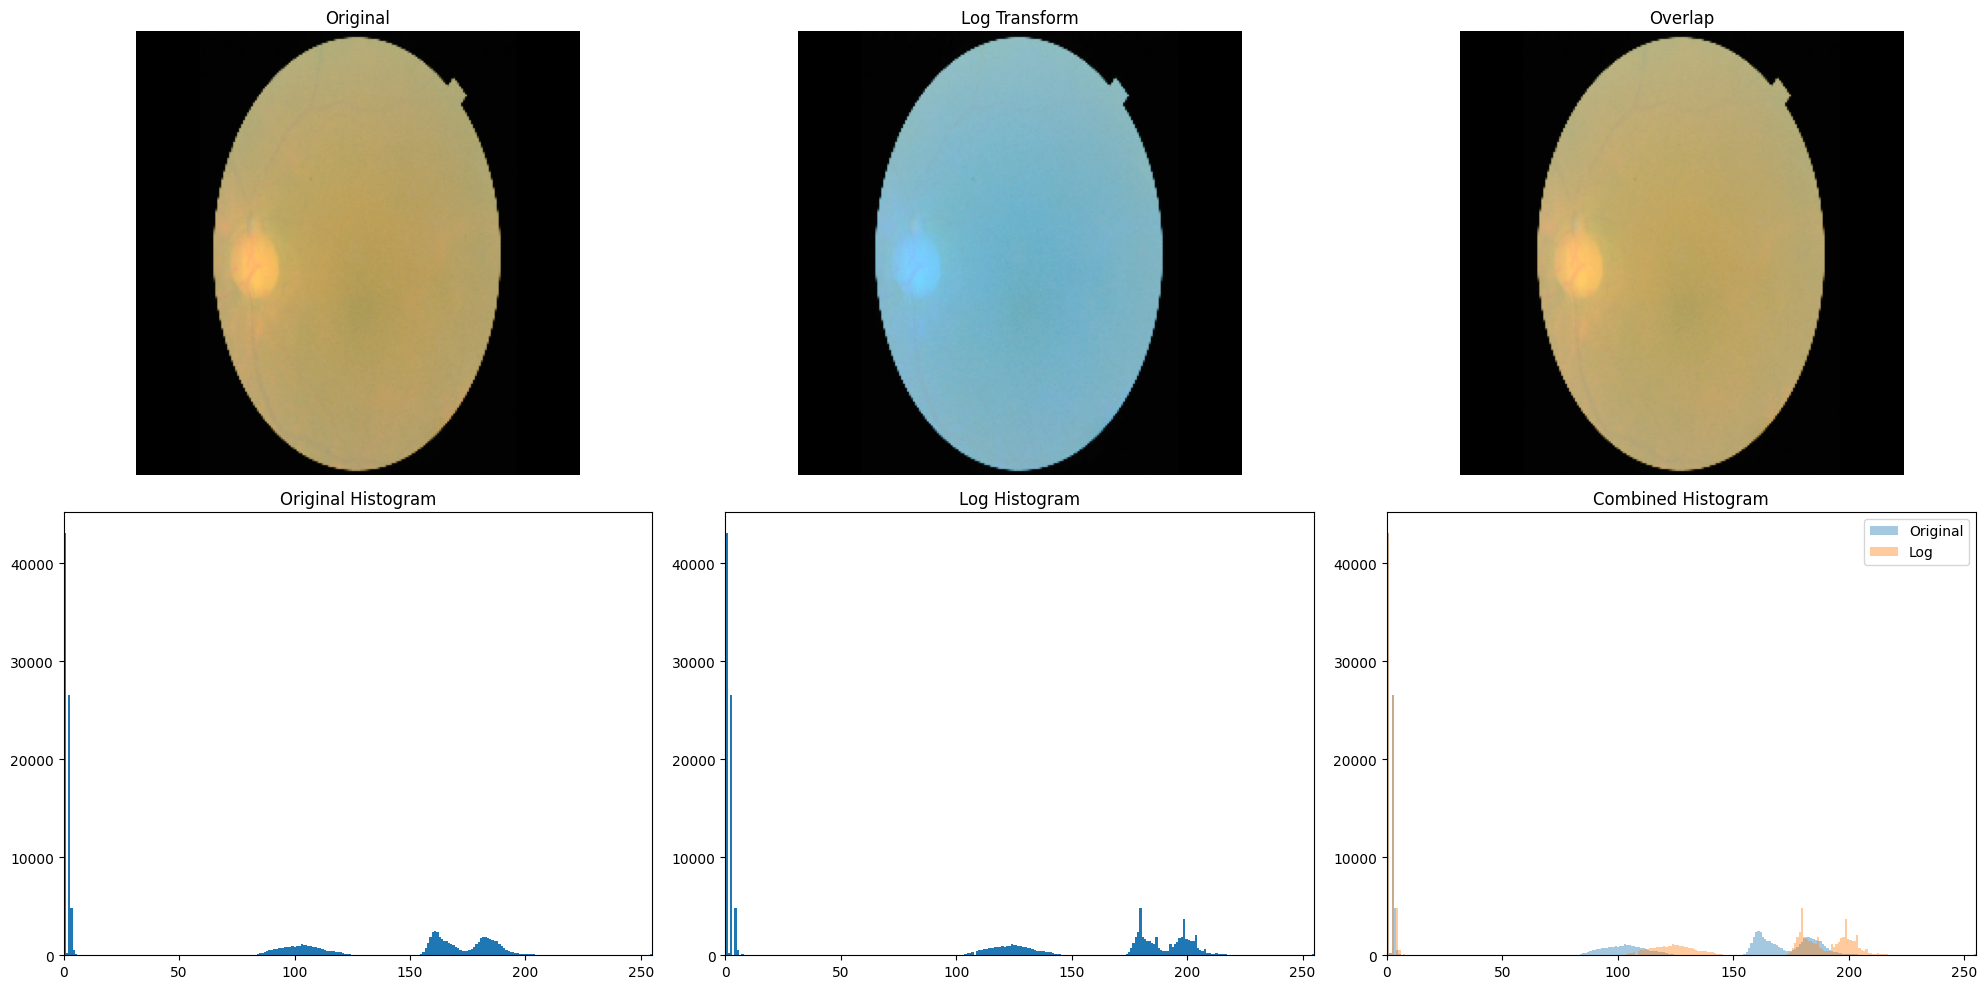

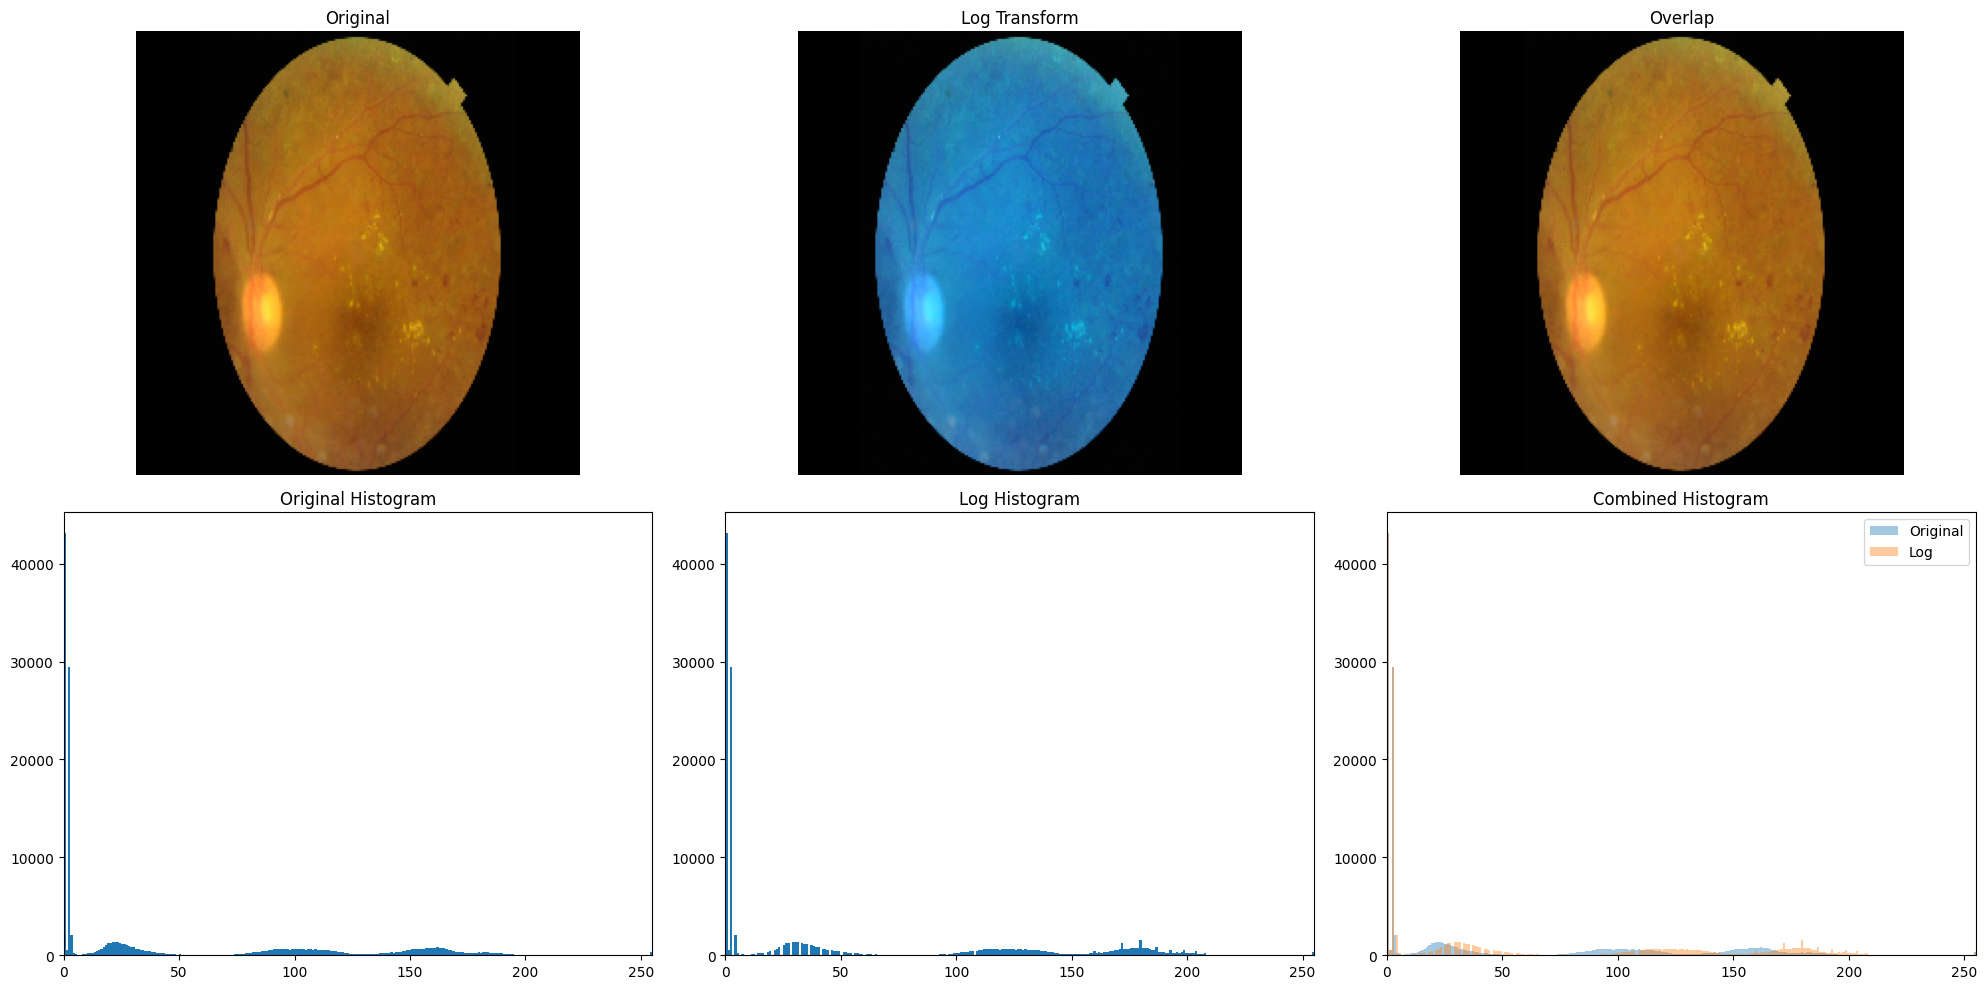

In [ ]:
sample_paths = image_paths[:5]

for path in sample_paths:
    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))

    # convert to tensor
    img_tensor = tf.convert_to_tensor(img)

    # Apply log transform (choose one)
    log_img = log_transform_c50(img_tensor)   # or log_transform_c150
    log_img = log_img.numpy()

    # Convert for OpenCV overlap
    log_uint8 = (log_img * 255).astype(np.uint8)

    # Overlap (RGB)
    overlap = cv2.addWeighted(img.astype(np.uint8), 0.7, log_uint8, 0.3, 0)

    plt.figure(figsize=(20, 10))

    # --- ROW 1 ---
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(log_img)
    plt.title("Log Transform")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(cv2.cvtColor(overlap, cv2.COLOR_BGR2RGB))
    plt.title("Overlap")
    plt.axis('off')

    log_hist = (log_img * 255).astype(np.uint8)

    # --- ROW 2 ---
    plt.subplot(2, 3, 4)
    plt.hist(img.ravel(), bins=256)
    plt.title("Original Histogram")
    plt.xlim(0, 255)

    plt.subplot(2, 3, 5)
    plt.hist(log_hist.ravel(), bins=256)
    plt.title("Log Histogram")
    plt.xlim(0, 255)

    plt.subplot(2, 3, 6)
    plt.hist(img.ravel(), bins=256, alpha=0.4, label='Original')
    plt.hist(log_hist.ravel(), bins=256, alpha=0.4, label='Log')
    plt.legend()
    plt.title("Combined Histogram")
    plt.xlim(0, 255)

    plt.tight_layout()
    plt.show()

In [ ]:
img, label = next(iter(val))

plt.figure(figsize=(10,10))

for i in range(5):
    # Adjusted subplot to 5 rows and 4 columns to accommodate 20 images
    plt.subplot(2, 3, i + 1)
    plt.imshow((img[i].numpy()*255).astype("uint8"))
    plt.title(f"Label: {label[i].numpy()}") # Removed [0] as label[i].numpy() is already a scalar
    plt.axis("off")

plt.show()

#Load ResNet50

In [ ]:
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Custom classifier
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    x = layers.Dropout(0.5)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    # Final model
    model = models.Model(inputs=base_model.input, outputs=output)
    return model


# Instantiate model
model = build_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


#Callback

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    mode='max')

#Class Imbalance

In [ ]:
labels_np = df["Disease_Risk"].to_numpy()

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_np),
    y=labels_np)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(2.3940149625935163), 1: np.float64(0.6319947333772219)}


#Complile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()])
history = model.fit(data,validation_data=val,epochs=15,class_weight=class_weights,callbacks=[early_stop])

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 2874s 29s/step - accuracy: 0.6328 - loss: 0.6708 - precision: 0.8485 - recall: 0.6524 - val_accuracy: 0.7906 - val_loss: 0.5959 - val_precision: 0.7906 - val_recall: 1.0000
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.6646 - loss: 0.6149 - precision: 0.8736 - recall: 0.6735 - val_accuracy: 0.2094 - val_loss: 2.8815 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.7557 - loss: 0.5659 - precision: 0.9082 - recall: 0.7689 - val_accuracy: 0.2094 - val_loss: 4.8848 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.7505 - loss: 0.5452 - precision: 0.9140 - recall: 0.7558 - val_accuracy: 0.2094 - val_loss: 4.8428 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.7677 - loss: 0.5206 - precision: 0.9162 - recall: 0.7775 - val_accuracy: 

#Evaluation

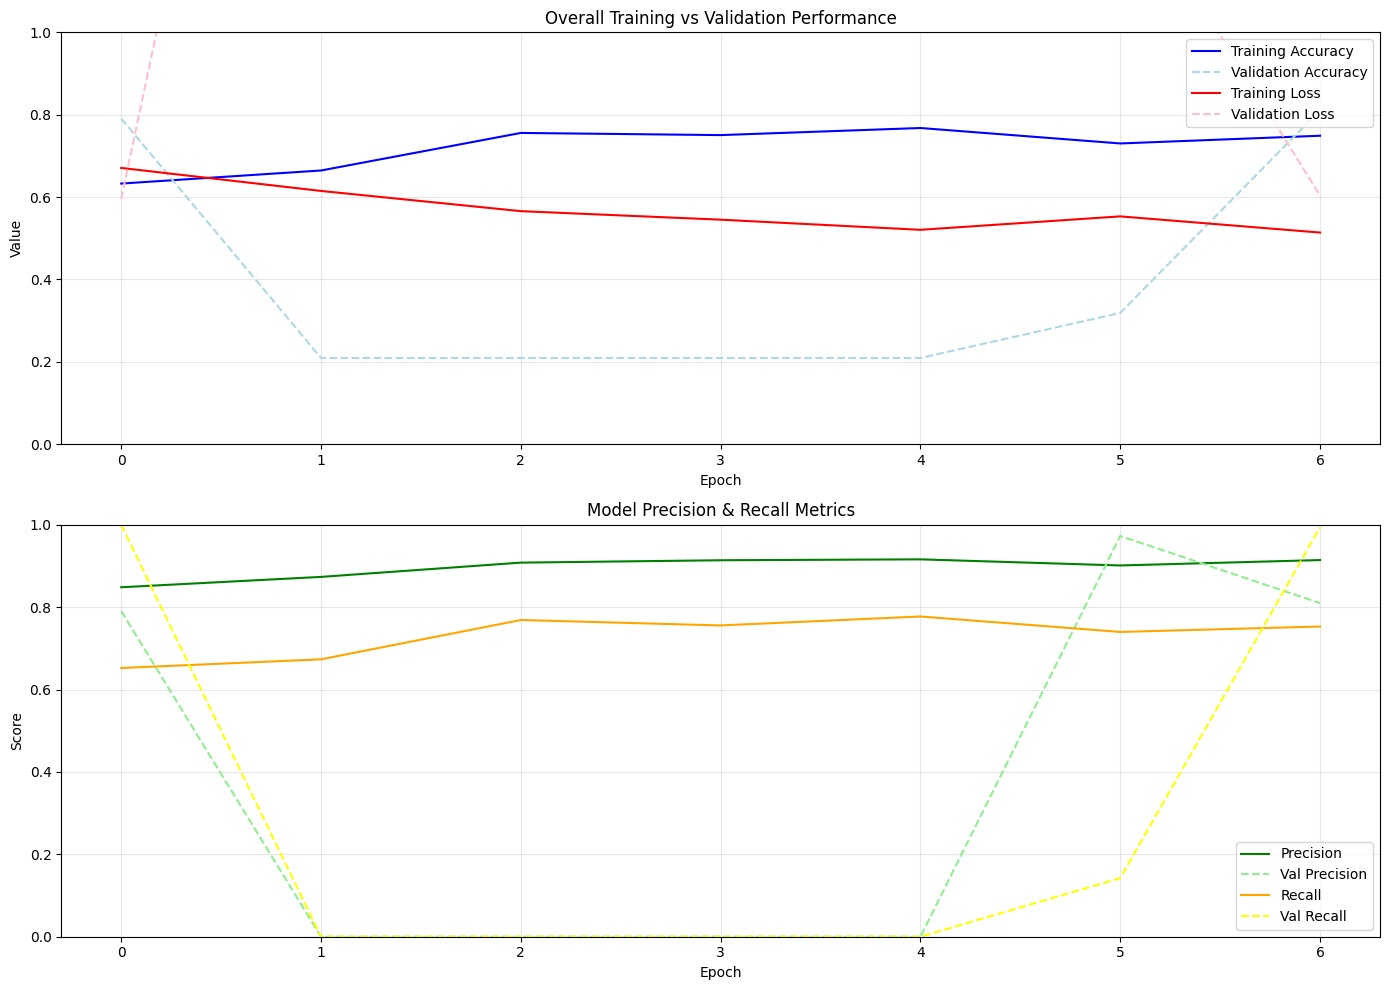

In [ ]:
plt.figure(figsize=(14, 10))

# 1. Accuracy and Loss (Your original requested plot)
plt.subplot(2, 1, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='lightblue', linestyle='--')
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='pink', linestyle='--')
plt.title("Overall Training vs Validation Performance")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.ylim([0, 1])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 2. Precision and Recall (The new requested plot)
plt.subplot(2, 1, 2)
plt.plot(history.history['precision'], label='Precision', color='green')
plt.plot(history.history['val_precision'], label='Val Precision', color='lightgreen', linestyle='--')
plt.plot(history.history['recall'], label='Recall', color='orange')
plt.plot(history.history['val_recall'], label='Val Recall', color='yellow', linestyle='--')
plt.title("Model Precision & Recall Metrics")
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc, test_recall, test_precision = model.evaluate(test)

print("Test Accuracy:", test_acc)
print("Test Recall:", test_recall)
print("Test Precision:", test_precision)

20/20 ━━━━━━━━━━━━━━━━━━━━ 703s 35s/step - accuracy: 0.2109 - loss: 4.9551 - precision: 1.0000 - recall: 0.0020
Test Accuracy: 0.2109375
Test Recall: 0.0019762846641242504
Test Precision: 1.0


#Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


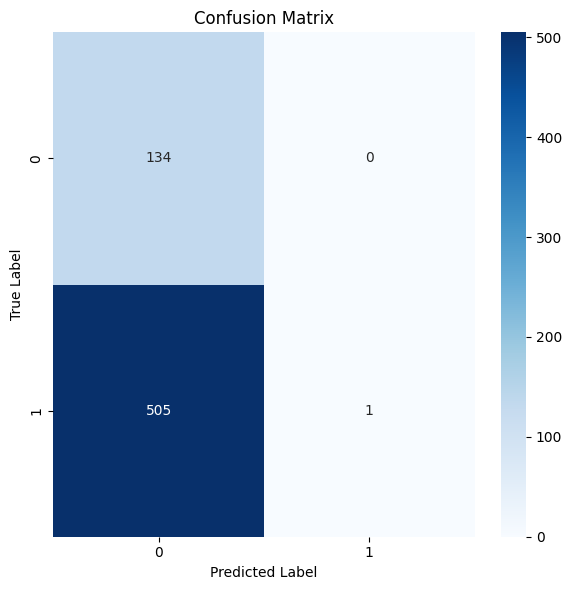

In [ ]:
# Get predictions
y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#Classification

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.21      1.00      0.35       134
           1       1.00      0.00      0.00       506

    accuracy                           0.21       640
   macro avg       0.60      0.50      0.18       640
weighted avg       0.83      0.21      0.08       640



#Calculation

In [ ]:
# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# etrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")

In [ ]:
import numpy as np

# Given confusion matrix
cm = np.array([[134, 0],
               [505, 1]])

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Metrics Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print Results
print("\nModel Performance:\n")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1_score:.4f}")


Model Performance:

Accuracy     : 0.2109
Precision    : 1.0000
Recall       : 0.0020
Specificity  : 1.0000
F1 Score     : 0.0039
